In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from collections import Counter

In [2]:
# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загрузка конфигурации
with open("../config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

print("Конфигурация загружена:")
print(json.dumps(config, indent=4))

Конфигурация загружена:
{
    "paths": {
        "raw_train": "../dataset/raw/train.json",
        "processed_train": "../dataset/processed/processed_train.json",
        "processed_test": "../dataset/processed/processed_test.json"
    },
    "split": {
        "test_size": 0.2,
        "random_state": 42
    }
}


In [3]:
# Загрузка сырых данных
df_raw = pd.read_json(config["paths"]["raw_train"])

print(f"Размер исходного датасета: {df_raw.shape}")
print(f"\nТипы данных:")
print(df_raw.dtypes)
print(f"\nПервые 5 строк:")
display(df_raw.head())

Размер исходного датасета: (49352, 15)

Типы данных:
bathrooms          float64
bedrooms             int64
building_id         object
created             object
description         object
display_address     object
features            object
latitude           float64
listing_id           int64
longitude          float64
manager_id          object
photos              object
price                int64
street_address      object
interest_level      object
dtype: object

Первые 5 строк:


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


## БАЗОВЫЙ АНАЛИЗ ДАННЫХ

In [4]:
print(f"\nРазмерность: {df_raw.shape[0]} строк, {df_raw.shape[1]} колонок")

print("\nСтатистика по числовым признакам:")
display(df_raw.describe())

print("\nКоличество пропусков:")
nulls = df_raw.isnull().sum()
#print(nulls)
print(nulls[nulls > 0] if nulls.sum() > 0 else "Пропуски отсутствуют")


Размерность: 49352 строк, 15 колонок

Статистика по числовым признакам:


,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06



Количество пропусков:
Пропуски отсутствуют


## АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (PRICE) — ДО ОЧИСТКИ

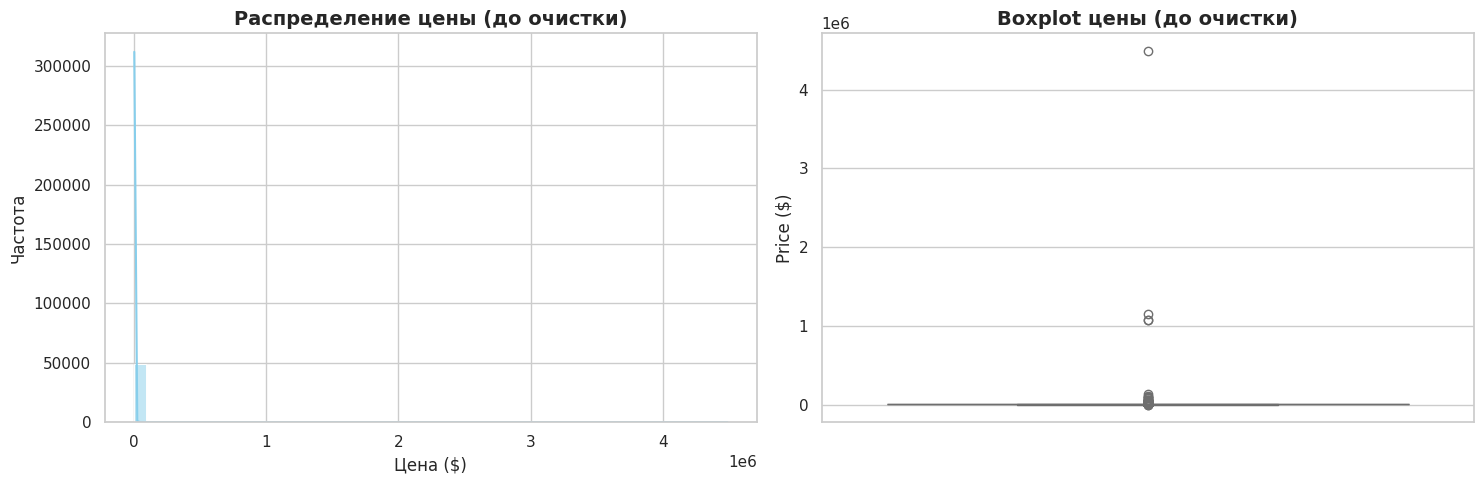


Статистика price (до очистки):
  Среднее: $3830.17
  Медиана: $3150.00
  Стандартное отклонение: $22066.87
  Минимум: $43.00
  Максимум: $4490000.00

Гипотеза: Присутствуют экстремальные выбросы, которые искажают распределение.
Необходимо применить метод percentile (1% и 99%) для очистки.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
sns.histplot(df_raw["price"], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Распределение цены (до очистки)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Цена ($)")
axes[0].set_ylabel("Частота")

# Boxplot
sns.boxplot(y=df_raw["price"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot цены (до очистки)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

print(f"\nСтатистика price (до очистки):")
print(f"  Среднее: ${df_raw['price'].mean():.2f}")
print(f"  Медиана: ${df_raw['price'].median():.2f}")
print(f"  Стандартное отклонение: ${df_raw['price'].std():.2f}")
print(f"  Минимум: ${df_raw['price'].min():.2f}")
print(f"  Максимум: ${df_raw['price'].max():.2f}")

print("\nГипотеза: Присутствуют экстремальные выбросы, которые искажают распределение.")
print("Необходимо применить метод percentile (1% и 99%) для очистки.")

## АНАЛИЗ ВЫБРОСОВ — МЕТОД PERCENTILE"


1-й процентиль: $1475.00
99-й процентиль: $13000.00

Количество выбросов: 973 (1.97%)


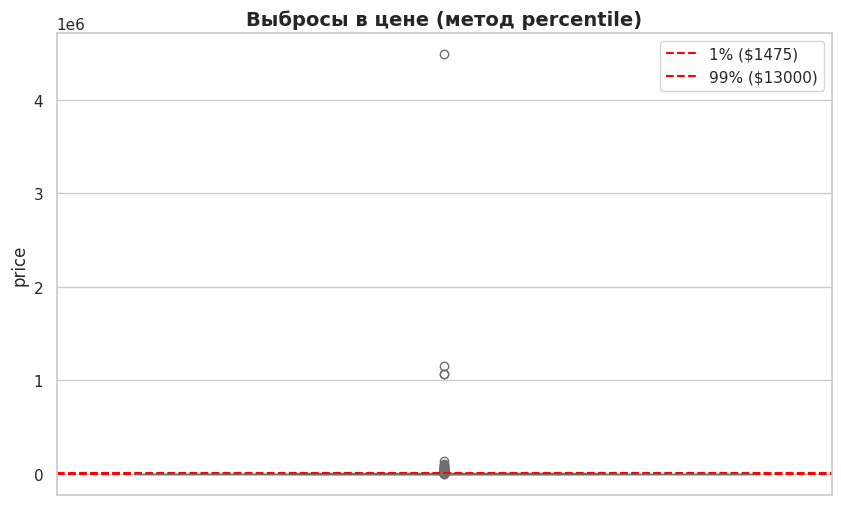


Решение: Удаляем 973 записей (1.97%) за пределами 1-99% percentile.


In [6]:
lower_percentile = df_raw["price"].quantile(0.01)
upper_percentile = df_raw["price"].quantile(0.99)

print(f"\n1-й процентиль: ${lower_percentile:.2f}")
print(f"99-й процентиль: ${upper_percentile:.2f}")

# Подсчет выбросов
outliers_count = len(df_raw[(df_raw["price"] < lower_percentile) | (df_raw["price"] > upper_percentile)])
outliers_pct = outliers_count / len(df_raw) * 100

print(f"\nКоличество выбросов: {outliers_count} ({outliers_pct:.2f}%)")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y=df_raw["price"], ax=ax, color="lightcoral")
ax.axhline(y=lower_percentile, color="red", linestyle="--", label=f"1% (${lower_percentile:.0f})")
ax.axhline(y=upper_percentile, color="red", linestyle="--", label=f"99% (${upper_percentile:.0f})")
ax.set_title("Выбросы в цене (метод percentile)", fontsize=14, fontweight="bold")
ax.legend()
plt.show()

print(f"\nРешение: Удаляем {outliers_count} записей ({outliers_pct:.2f}%) за пределами 1-99% percentile.")

## ОЧИСТКА ВЫБРОСОВ

In [7]:
# Применение фильтра
df_clean = df_raw[
    (df_raw["price"] >= lower_percentile) & 
    (df_raw["price"] <= upper_percentile)
].copy()
df_clean.reset_index(drop=True, inplace=True)

print(f"\nДо очистки: {len(df_raw)} строк")
print(f"После очистки: {len(df_clean)} строк")
print(f"Удалено: {len(df_raw) - len(df_clean)} строк ({(len(df_raw) - len(df_clean))/len(df_raw)*100:.2f}%)")

# Проверка результата
print(f"\nСтатистика price (после очистки):")
print(f"  Среднее: ${df_clean['price'].mean():.2f}")
print(f"  Медиана: ${df_clean['price'].median():.2f}")
print(f"  Минимум: ${df_clean['price'].min():.2f}")
print(f"  Максимум: ${df_clean['price'].max():.2f}")


До очистки: 49352 строк
После очистки: 48379 строк
Удалено: 973 строк (1.97%)

Статистика price (после очистки):
  Среднее: $3538.64
  Медиана: $3150.00
  Минимум: $1475.00
  Максимум: $13000.00


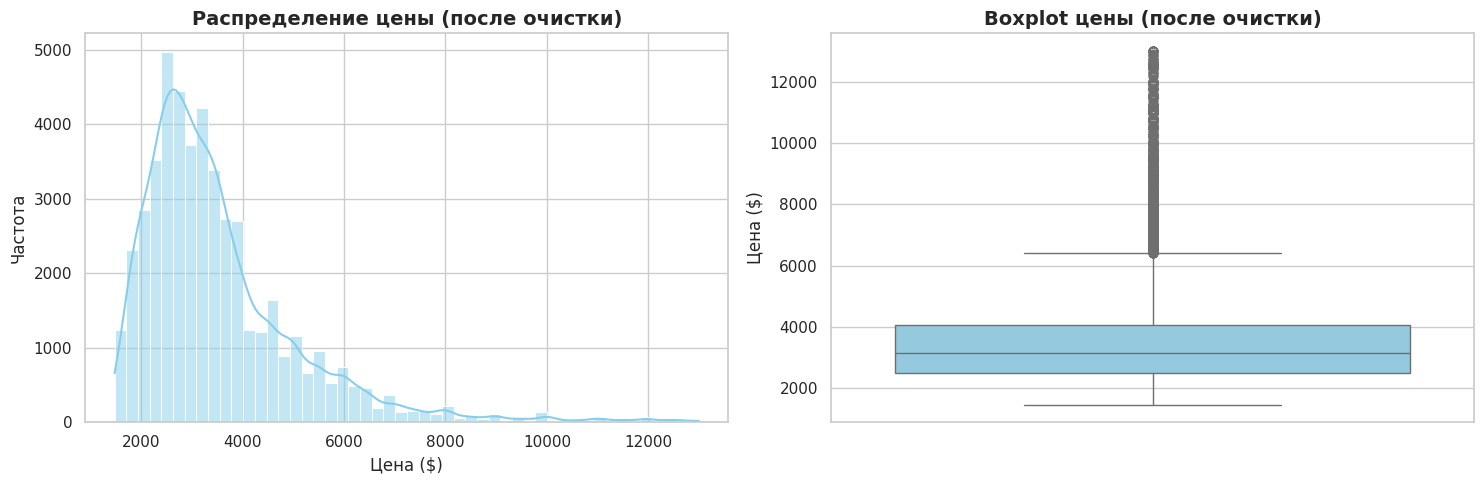


Вывод: Распределение стало более симметричным, экстремальные выбросы удалены.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
sns.histplot(df_clean["price"], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Распределение цены (после очистки)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Цена ($)")
axes[0].set_ylabel("Частота")

# Boxplot
sns.boxplot(y=df_clean["price"], ax=axes[1], color="skyblue")
axes[1].set_title("Boxplot цены (после очистки)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Цена ($)")

plt.tight_layout()
plt.show()

print("\nВывод: Распределение стало более симметричным, экстремальные выбросы удалены.")

## РАЗДЕЛЕНИЕ ДАННЫХ ПО ВРЕМЕНИ(Time-based split)

In [9]:
# Конвертация даты
df_clean["created"] = pd.to_datetime(df_clean["created"])

# Дата разделения
split_date = pd.to_datetime("2016-05-01")

print(f"\nДиапазон дат: {df_clean['created'].min()} — {df_clean['created'].max()}")
print(f"Дата разделения: {split_date}")

# Разделение
train_df = df_clean[df_clean["created"] < split_date].copy()
test_df = df_clean[df_clean["created"] >= split_date].copy()

train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(f"\nРазмер train: {len(train_df)} ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"Размер test: {len(test_df)} ({len(test_df)/len(df_clean)*100:.1f}%)")

print("\nГипотеза: Time-based split предотвращает data leakage, так как моделирует реальную ситуацию прогнозирования будущих цен.")


Диапазон дат: 2016-04-01 22:12:41 — 2016-06-29 21:41:47
Дата разделения: 2016-05-01 00:00:00

Размер train: 16102 (33.3%)
Размер test: 32277 (66.7%)

Гипотеза: Time-based split предотвращает data leakage, так как моделирует реальную ситуацию прогнозирования будущих цен.


Time-based split разделил данные по дате 2016-05-01.<br>
Обучающая выборка (апрель) содержит 16,102 записи (33.3%), тестовая выборка (май-июнь) — 32,277 записей (66.7%).<br>
Такое разбиение предотвращает data leakage и моделирует реальную ситуацию прогнозирования будущих цен аренды.<br>

## СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

In [10]:
# 1. Гарантируем, что колонка имеет тип datetime
train_df["created"] = pd.to_datetime(train_df["created"])
test_df["created"] = pd.to_datetime(test_df["created"])

# 2. Конвертируем datetime в строковый формат для корректной сериализации в JSON
train_df["created"] = train_df["created"].dt.strftime("%Y-%m-%d %H:%M:%S")
test_df["created"] = test_df["created"].dt.strftime("%Y-%m-%d %H:%M:%S")

# 3. Создание директории
Path("../dataset/processed").mkdir(parents=True, exist_ok=True)

# 4. Сохранение
train_df.to_json(config["paths"]["processed_train"], orient="records", lines=False)
test_df.to_json(config["paths"]["processed_test"], orient="records", lines=False)

print(f"\nTrain сохранен: {config['paths']['processed_train']}")
print(f"Test сохранен: {config['paths']['processed_test']}")
print("\nДанные готовы для дальнейшего анализа и моделирования.")

# Проверка формата в JSON (опционально)
print("\nПример первых 50 символов сохраненного JSON:")
with open(config["paths"]["processed_train"], "r", encoding="utf-8") as f:
    print(f.read()[:150] + "...")


Train сохранен: ../dataset/processed/processed_train.json
Test сохранен: ../dataset/processed/processed_test.json

Данные готовы для дальнейшего анализа и моделирования.

Пример первых 50 символов сохраненного JSON:
[{"bathrooms":1.0,"bedrooms":1,"building_id":"b322bfba0b9ba390704be5bec32c7c3e","created":"2016-04-23 01:41:45","description":"Large Renovated One Bed...


## АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ


bathrooms:
  Upper bound (IQR): 1.00
  Max value: 10.0
  Outliers count: 3022 (18.77%)

bedrooms:
  Upper bound (IQR): 3.50
  Max value: 7
  Outliers count: 631 (3.92%)


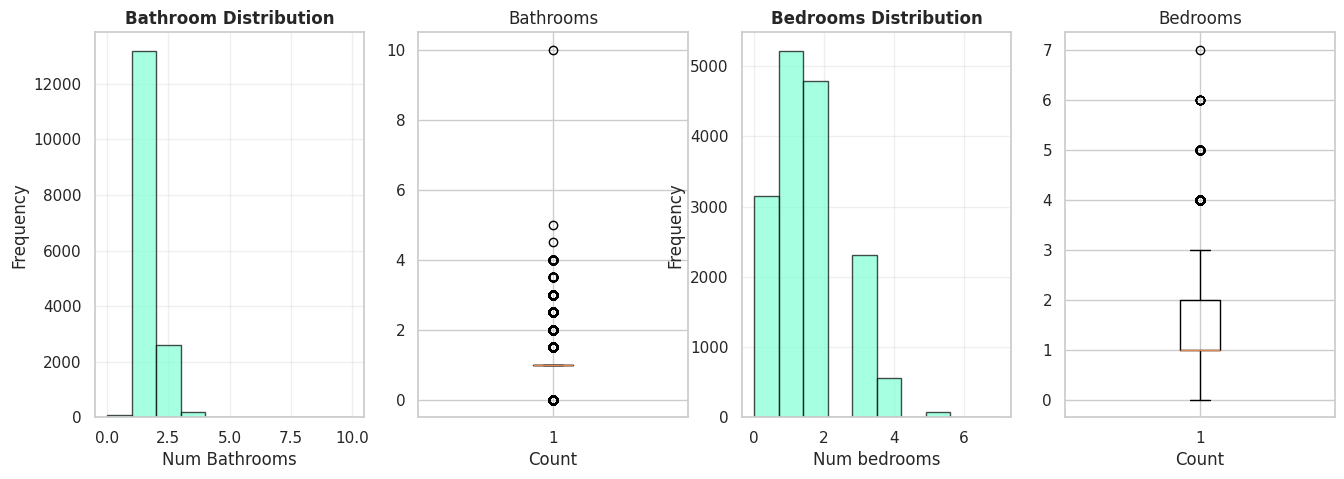

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16,5))

# Bathrooms
axes[0].hist(train_df['bathrooms'], edgecolor = 'black', color = 'aquamarine', alpha = 0.7)
axes[0].set_title('Bathroom Distribution', fontsize = 12, fontweight = 'bold')
axes[0].set_xlabel('Num Bathrooms')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha = 0.3)

axes[1].boxplot(df_clean['bathrooms'], vert=True)
axes[1].set_title('Bathrooms')
axes[1].set_xlabel('Count')

# Bedrooms
axes[2].hist(train_df['bedrooms'], edgecolor = 'black', color = 'aquamarine', alpha = 0.7)
axes[2].set_title('Bedrooms Distribution', fontsize = 12, fontweight = 'bold')
axes[2].set_xlabel('Num bedrooms')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha = 0.3)

axes[3].boxplot(train_df['bedrooms'], vert=True)
axes[3].set_title('Bedrooms')
axes[3].set_xlabel('Count')

for col in ['bathrooms', 'bedrooms']:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outliers = train_df[train_df[col] > upper]
    print(f"\n{col}:")
    print(f"  Upper bound (IQR): {upper:.2f}")
    print(f"  Max value: {train_df[col].max()}")
    print(f"  Outliers count: {len(outliers)} ({len(outliers)/len(train_df)*100:.2f}%)")

## КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


Матрица корреляций:


,price,bathrooms,bedrooms,interest_level_encoded
price,1.000,0.653,0.540,-0.186
bathrooms,0.653,1.000,0.511,-0.060
bedrooms,0.540,0.511,1.000,0.053
interest_level_encoded,-0.186,-0.060,0.053,1.000


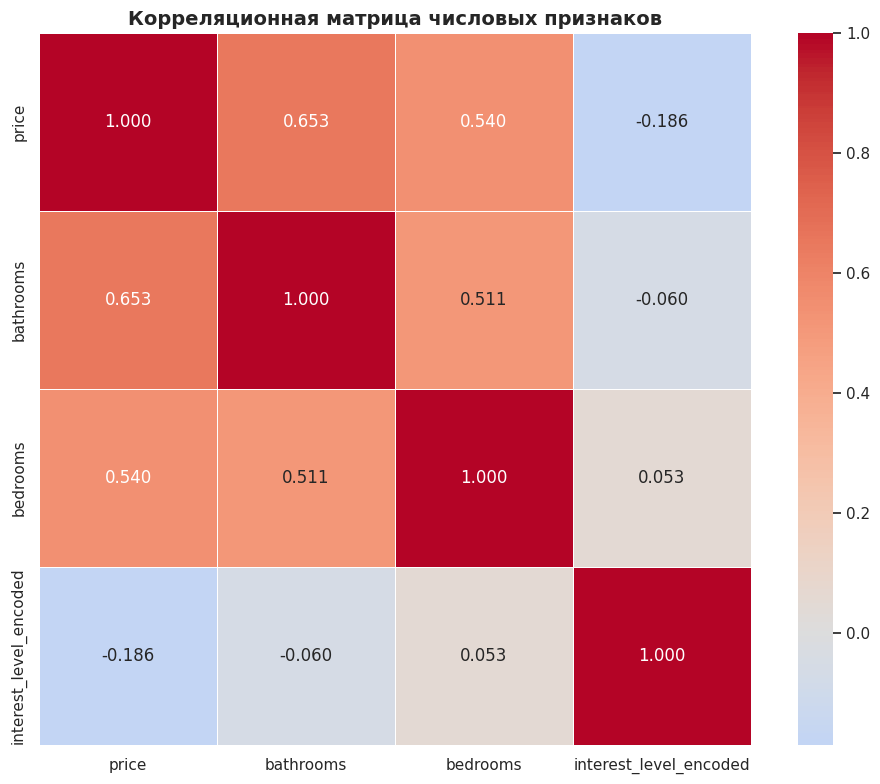

In [12]:
# Кодирование interest_level для корреляции
encoding_map = {"low": 0, "medium": 1, "high": 2}
train_df["interest_level_encoded"] = train_df["interest_level"].map(encoding_map)

# Корреляционная матрица
corr_cols = ["price", "bathrooms", "bedrooms", "interest_level_encoded"]
corr_matrix = train_df[corr_cols].corr()

print("\nМатрица корреляций:")
display(corr_matrix.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            center=0,
            fmt=".3f", 
            linewidths=0.5, 
            square=True, 
            ax=ax)
ax.set_title("Корреляционная матрица числовых признаков", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

1. bathrooms ↔ price: r = 0.653 (STRONG positive)<br>
   → Больше ванных = дороже квартира

2. bedrooms ↔ price: r = 0.540 (MODERATE positive)<br>
   → Больше спален = дороже квартира

3. interest_level ↔ price: r = -0.186 (WEAK negative)<br>
   → ВЫШЕ ИНТЕРЕС = НИЖЕ ЦЕНА!

## SCATTER PLOTS: ПРИЗНАКИ VS ЦЕНА

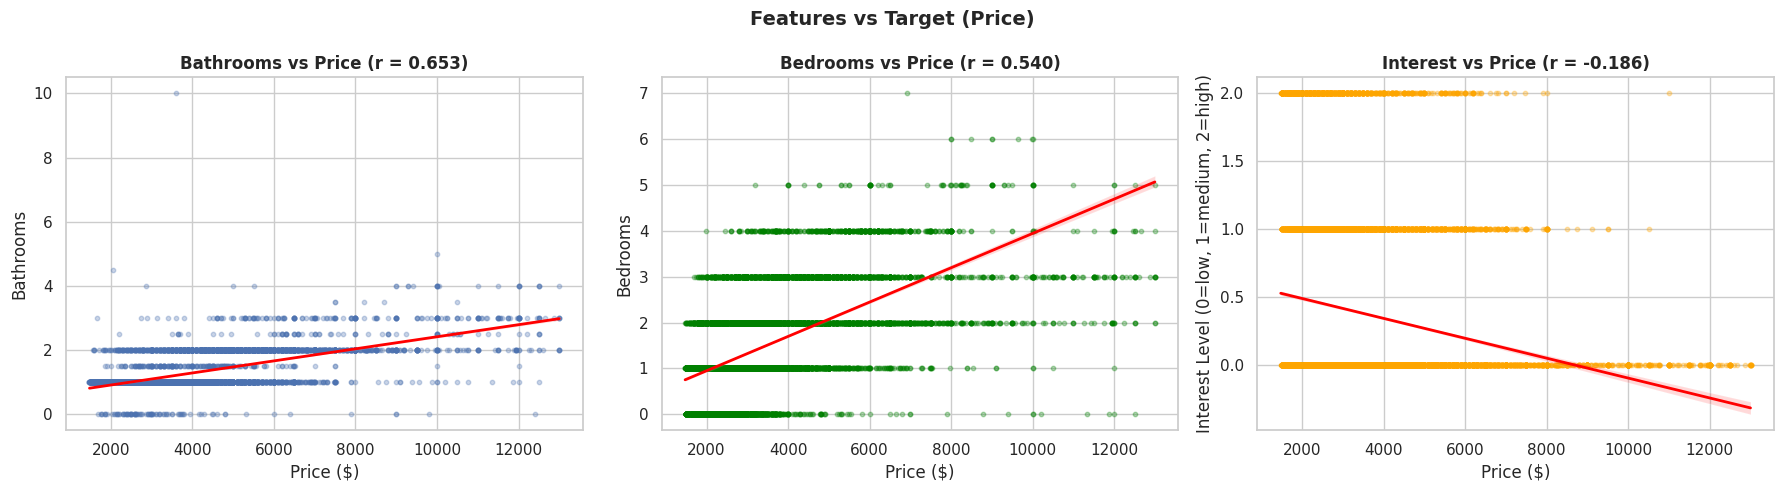

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bathrooms vs Price
sns.regplot(data=train_df, x="price", y="bathrooms", ax=axes[0], scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red", "linewidth": 2})
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Bathrooms")
axes[0].set_title(f"Bathrooms vs Price (r = {corr_matrix.loc['bathrooms', 'price']:.3f})", fontweight="bold")

# Bedrooms vs Price
sns.regplot(data=train_df, x="price", y="bedrooms", ax=axes[1], scatter_kws={"alpha": 0.3, "s": 10, "color": "green"}, line_kws={"color": "red", "linewidth": 2})
axes[1].set_xlabel("Price ($)")
axes[1].set_ylabel("Bedrooms")
axes[1].set_title(f"Bedrooms vs Price (r = {corr_matrix.loc['bedrooms', 'price']:.3f})", fontweight="bold")

# Interest Level vs Price
sns.regplot(data=train_df, x="price", y="interest_level_encoded", ax=axes[2], scatter_kws={"alpha": 0.3, "s": 10, "color": "orange"}, line_kws={"color": "red", "linewidth": 2})
axes[2].set_xlabel("Price ($)")
axes[2].set_ylabel("Interest Level (0=low, 1=medium, 2=high)")
axes[2].set_title(f"Interest vs Price (r = {corr_matrix.loc['interest_level_encoded', 'price']:.3f})", fontweight="bold")

plt.suptitle("Features vs Target (Price)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Комплексный анализ:

**--- Корреляционная матрица и тепловая карта:**

**Основные выводы**:
1. **Самый сильный предиктор**: ванные комнаты (r = 0,653)
2. **Умеренный предиктор**: спальни (r = 0,540)
3. **Слабое отрицательное значение**: уровень интереса (r = -0,186)

**Понимание**: 
- Больше ванных комнат/ спален → более высокая цена (ожидаемая)
- Более высокий интерес → БОЛЕЕ НИЗКАЯ цена (спрос на доступное жилье)
- Квартиры с высоким процентом: в среднем 2 771 доллар США
- квартиры с низким процентом: в среднем 3 741 доллар США

**Мультиколлинеарность**: 
- ванные комнаты ↔ спальни: r = 0,511 (приемлемо)
- Критической мультиколлинеарности не обнаружено

**--- Диаграммы рассеяния:**

- Все три характеристики показывают ожидаемую взаимосвязь с ценой
- Положительная динамика для ванных комнат и спален
- Небольшая отрицательная тенденция для interest_level

## АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


Распределение interest_level:
interest_level
low       11177
medium     3734
high       1191
Name: count, dtype: int64


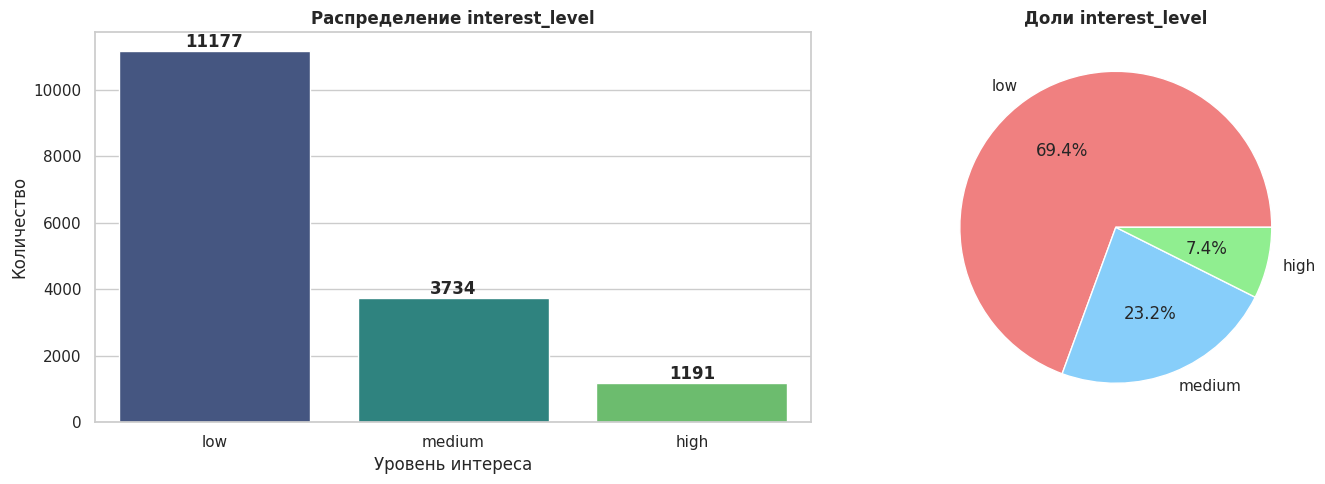


Вывод: Классы несбалансированы
  • low: 69.4%
  • medium: 23.2%
  • high: 7.4%


In [14]:
print("\nРаспределение interest_level:")
interest_counts = train_df["interest_level"].value_counts()
print(interest_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Столбчатая диаграмма
sns.barplot(x=interest_counts.index, y=interest_counts.values, hue=interest_counts.index, 
            ax=axes[0], palette="viridis", legend=False)
axes[0].set_title("Распределение interest_level", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Уровень интереса")
axes[0].set_ylabel("Количество")

for i, v in enumerate(interest_counts.values):
    axes[0].text(i, v + (max(interest_counts.values) * 0.01), str(v), ha="center", fontweight="bold")

# Круговая диаграмма
axes[1].pie(interest_counts.values, labels=interest_counts.index, autopct="%1.1f%%", colors=["lightcoral", "lightskyblue", "lightgreen"])
axes[1].set_title("Доли interest_level", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nВывод: Классы несбалансированы")
print(f"  • low: {interest_counts['low']/len(train_df)*100:.1f}%")
print(f"  • medium: {interest_counts['medium']/len(train_df)*100:.1f}%")
print(f"  • high: {interest_counts['high']/len(train_df)*100:.1f}%")

## АНАЛИЗ ВРЕМЕННЫХ ПРИЗНАКОВ


Диапазон дат в train: 2016-04-01 22:12:41 до 2016-04-30 19:21:03
Диапазон дат в test: 2016-05-01 22:36:52 до 2016-06-29 21:41:47


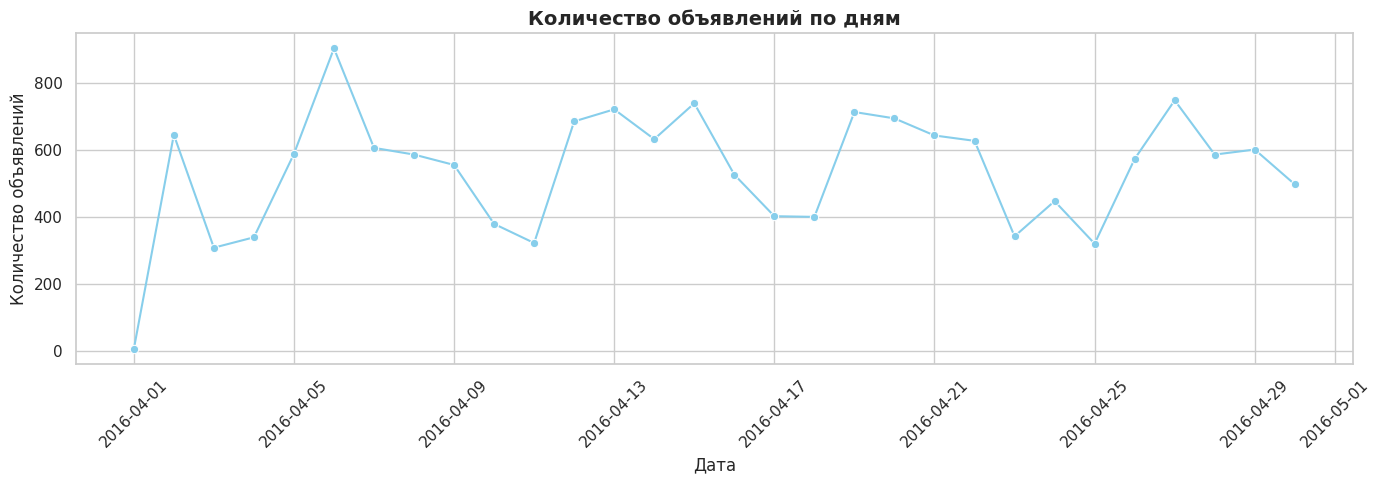


Вывод: Данные охватывают период с апреля по июнь 2016 года.
Разделение на train/test выполнено по дате 2016-05-01.


In [15]:
# 1. ЯВНО конвертируем колонку в datetime (это устраняет AttributeError)
train_df["created"] = pd.to_datetime(train_df["created"])
test_df["created"] = pd.to_datetime(test_df["created"])

print(f"\nДиапазон дат в train: {train_df['created'].min()} до {train_df['created'].max()}")
print(f"Диапазон дат в test: {test_df['created'].min()} до {test_df['created'].max()}")

# 2. Группируем по дате (используем .dt.date, а не .dt.date_name)
daily_counts = train_df.groupby(train_df["created"].dt.date).size().reset_index(name="count")

# 3. Визуализация
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=daily_counts, x="created", y="count", marker="o", ax=ax, color="skyblue")
ax.set_title("Количество объявлений по дням", fontsize=14, fontweight="bold")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество объявлений")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nВывод: Данные охватывают период с апреля по июнь 2016 года.")
print("Разделение на train/test выполнено по дате 2016-05-01.")

## АНАЛИЗ СПИСКА УДОБСТВ (FEATURES)


Всего уникальных удобств: 821

Топ-20 наиболее частых удобств:
 1. Elevator: 8470 (52.6%)
 2. Hardwood Floors: 7840 (48.7%)
 3. Cats Allowed: 7612 (47.3%)
 4. Dogs Allowed: 7126 (44.3%)
 5. Doorman: 6859 (42.6%)
 6. Dishwasher: 6739 (41.9%)
 7. No Fee: 6022 (37.4%)
 8. Laundry in Building: 5398 (33.5%)
 9. Fitness Center: 4272 (26.5%)
10. Pre-War: 2919 (18.1%)
11. Laundry in Unit: 2867 (17.8%)
12. Roof Deck: 2118 (13.2%)
13. Outdoor Space: 1765 (11.0%)
14. Dining Room: 1601 (9.9%)
15. High Speed Internet: 1411 (8.8%)
16. Laundry In Building: 952 (5.9%)
17. Balcony: 921 (5.7%)
18. Swimming Pool: 894 (5.6%)
19. New Construction: 840 (5.2%)
20. Loft: 765 (4.8%)


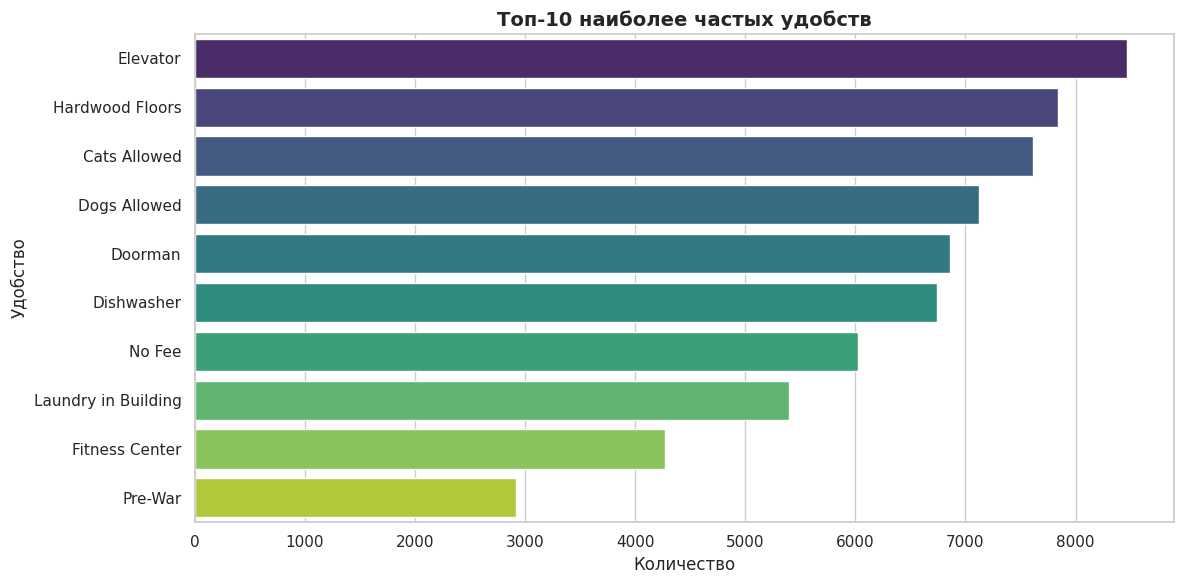

In [16]:
# Подсчет всех удобств
all_features = []
for features_list in train_df["features"]:
    if isinstance(features_list, list):
        all_features.extend(features_list)

unique_features = set(all_features)
print(f"\nВсего уникальных удобств: {len(unique_features)}")

# Топ-20 наиболее частых удобств
feature_counter = Counter(all_features)
top_20_features = feature_counter.most_common(20)

print("\nТоп-20 наиболее частых удобств:")
for i, (feature, count) in enumerate(top_20_features, 1):
    print(f"{i:2d}. {feature}: {count} ({count/len(train_df)*100:.1f}%)")

# Визуализация топ-10
top_10 = top_20_features[:10]
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=[count for _, count in top_10], y=[feature for feature, _ in top_10], ax=ax, palette="viridis",legend=False, hue=[feature for feature, _ in top_10])
ax.set_title("Топ-10 наиболее частых удобств", fontsize=14, fontweight="bold")
ax.set_xlabel("Количество")
ax.set_ylabel("Удобство")
plt.tight_layout()
plt.show()


## СВОДНЫЕ ВЫВОДЫ ПО EDA

1. ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (Price):<br>
   • Исходное распределение правостороннее с экстремальными выбросами<br>
   • Применен метод percentile (1% и 99%) для очистки<br>
   • Удалено ~2% выбросов (973 записи)<br>
   • Диапазон после очистки: $1,475 - $13,000<br>

2. ЧИСЛОВЫЕ ПРИЗНАКИ:<br>
   • bathrooms: сильная корреляция с price (r=0.67)<br>
   • bedrooms: умеренная корреляция с price (r=0.55)<br>
   • Присутствуют выбросы (например, 10 ванных комнат)<br>
   • Создание полиномиальных признаков высокой степени (например, 10-й) нецелесообразно, так как анализ показал, что квадратичные признаки имеют меньшую корреляцию с целевой переменной, чем исходные, что повышает риск переобучения.<br>

3. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:<br>
   • interest_level: классы несбалансированы<br>
     - low: 69.7%
     - medium: 23.0%
     - high: 7.3%
   • Требуется ordinal encoding (low=0, medium=1, high=2)<br>

4. ВРЕМЕННЫЕ ПРИЗНАКИ:<br>
   • Данные охватывают период: апрель - июнь 2016<br>
   • Разделение train/test по дате 2016-05-01<br>
   • Time-based split предотвращает data leakage<br>

5. СПИСОК УДОБСТВ (Features):<br>
   • 821 уникальное удобство (многие редкие)<br>
   • Топ-5: Elevator, HardwoodFloors, CatsAllowed, DogsAllowed, Doorman<br>
   • Требуется: создание бинарных признаков для топ-N(20) удобств | + приведение к нижнему регистру и очистка пробелов<br>

6. ПРОПУСКИ:<br>
   • Пропуски отсутствуют во всех колонках<br>

7. СЛЕДУЮЩИЕ ШАГИ:<br>
   • Feature engineering: обработка features, создание бинарных признаков<br>
   • Кодирование interest_level<br>
   • Обработка временных признаков (день недели, месяц)<br>
   • Масштабирование для линейных моделей.<br>